## Boston Marathon Project - Weather Analysis
#### Scott Bradley

### Weather Analysis Goal
##### While the primary analysis studies differences in finish times between different categories and demographics, this secondary analysis studies external factors that may indicates overall trends in finish times across the years. 
Many runners believe weather plays a key factor in comfort and overall performance during a race. For the Boston Marathon in particular, runners have been training over the winter for a spring marathon, but April in boston has notoriously unpredictable weather conditions. The marathon day has seen all kinds of weather between freezing rain and 80+ degree days. 
So, this study aims to find any correlations between weather conditions and finish times across all demographics. We'll see which demographics are affected by weather more or less, and which conditions indicate positive or negative results.

## Data
#### Weather
The weather data is collected through the [Meteostat](https://dev.meteostat.net/python) python library. This library contains historic hourly weather and climate data for many US weather stations. It provides easy access to a buld data interface aggregating information from national weather services.

The key weather data for this study is hourly weather in the boston area during the marathon each year. Given that the Boston marathon staggers start times for it's **~26,000** each year, the weather for different runners may vary slightly depending on their start and finish times. To provide general trend analysis, the hourly weather is averaged over the window of **8 am - 6 pm**. We'll store and analyze the following weather parameters for that window each year: **Temperature (min, max, mean), Humidity, Wind Speed (mph), and Precipitation (in)**. 

The weather data will be the **independent variable** for this study.

In [1]:
import pandas as pd
import meteostat as ms
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Boston Logan station
station = ms.stations.meta('72509')

# All Boston Marathon dates for 2000-2019
dates = [
    "2000-04-17","2001-04-16","2002-04-15","2003-04-21",
    "2004-04-19","2005-04-18","2006-04-17","2007-04-16",
    "2008-04-21","2009-04-20","2010-04-19","2011-04-18",
    "2012-04-16","2013-04-15","2014-04-21","2015-04-20",
    "2016-04-18","2017-04-17","2018-04-16","2019-04-15"
]

weather_data = []

for d in dates:
    # Assume marathon takes place between 8 am and 6 pm
    start = datetime.strptime(d + " 10:00", "%Y-%m-%d %H:%M")
    end = datetime.strptime(d + " 18:00", "%Y-%m-%d %H:%M")

    ts = ms.hourly(station, start, end)
    data = ts.fetch()

    # Keep only relevant columns
    cols = [c for c in ["time", "temp", "rhum", "wspd", "prcp"] if c in data.columns]

    # Convert units
    if "wspd" in data.columns:
        data["wind_mph"] = data["wspd"] * 0.621371
    if "prcp" in data.columns:
        data["precip_in"] = data["prcp"] / 25.4
    if "temp" in data.columns:
        data["temp"] = data["temp"] * 9/5 + 32

    weather_data.append(data)

# Hourly data csv
df = pd.concat(weather_data)
df.index = pd.to_datetime(df.index)
df.to_csv("boston_hourly_weather.csv")

# Create summary for each marathon year
weather_summary = df.resample("D").agg(
    mean_temp=("temp","mean"),
    min_temp=("temp","min"),
    max_temp=("temp","max"),
    mean_humidity=("rhum","mean"),
    mean_wind_mph=("wind_mph","mean"),
    total_precip_in=("precip_in","sum")
)

# Keep only marathon dates
weather_summary = weather_summary.loc[pd.to_datetime(dates)]
weather_summary = weather_summary.round(3)
weather_summary.to_csv("boston_weather_summary.csv")

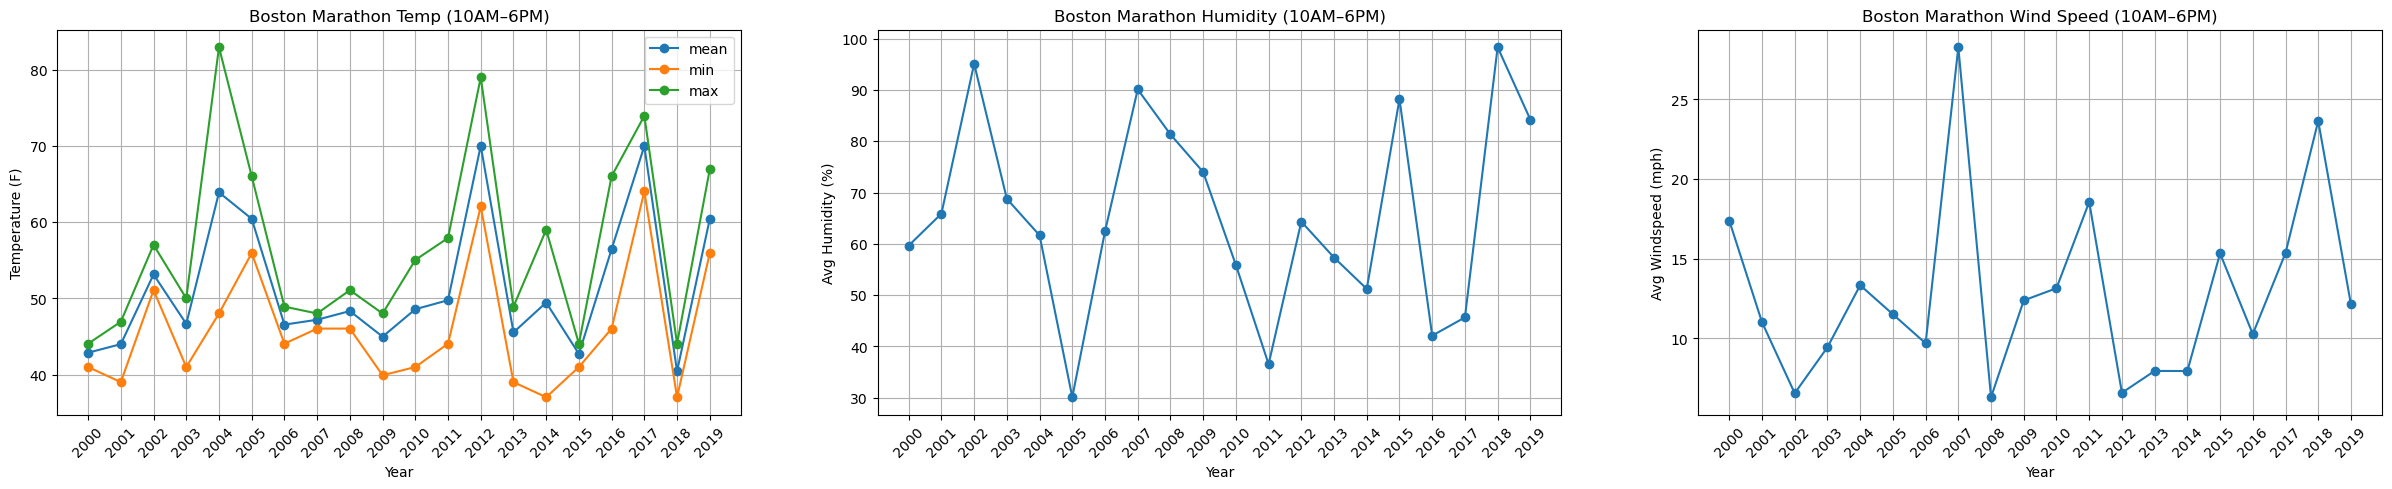

In [3]:
# Plot average humidity and temperature for each year
years = list(range(2000, 2020))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex=True, figsize=(30,5))
ax1.plot(years, weather_summary["mean_temp"], marker="o", label="mean")
ax1.plot(years, weather_summary["min_temp"], marker="o", label="min")
ax1.plot(years, weather_summary["max_temp"], marker="o", label="max")
ax1.set_ylabel("Temperature (F)")
ax1.set_xlabel("Year")
ax1.set_title("Boston Marathon Temp (10AM–6PM)")
ax1.set_xticks(years)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)
ax1.legend()

ax2.plot(years, weather_summary["mean_humidity"], marker="o")
ax2.set_ylabel("Avg Humidity (%)")
ax2.set_xlabel("Year")
ax2.set_title("Boston Marathon Humidity (10AM–6PM)")
ax2.set_xticks(years)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

ax3.plot(years, weather_summary["mean_wind_mph"], marker="o")
ax3.set_ylabel("Avg Windspeed (mph)")
ax3.set_xlabel("Year")
ax3.set_title("Boston Marathon Wind Speed (10AM–6PM)")
ax3.set_xticks(years)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True)

plt.show()

## Data
#### Boston Marathon Times
A key analysis grouping for this study will be **age groups**. For Boston marathon, qualifying and finish times are most commonly broken down into 5 year age groups. The data for years **2000-2019** contain all finishing times for the runners and their respective age group, so those will be the years covered. 

Out of all metrics recorded, we will collect: "year", "display_name", "age", "gender", "official_time", "seconds"

This finish time data will be the **dependent variable** for this study. Each age group contains ~19 years of observations

In [4]:
# Create age groups
def age_group(age):
    age = int(age)
    if age < 35:
        return "<35"
    elif age < 40:
        return "35-39"
    elif age < 45:
        return "40-44"
    elif age < 50:
        return "45-49"
    elif age < 55:
        return "50-54"
    elif age < 60:
        return "55-59"
    elif age < 65:
        return "60-64"
    elif age < 70:
        return  "65-69"
    elif age < 75:
        return "70-74"
    elif age < 80:
        return "75-79"
    else:
        return "80+"

# Order of the groups
age_order = [
    "<35",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64",
    "65-69",
    "70-74",
    "75-79"
]

# Make compiled runner times data
runner_data = []
grouped_data = []
for year in list(range(2000, 2020)):
    file = "times/" + f"results{year}.csv"
    df = pd.read_csv(file, na_values=["NULL"],engine="python",on_bad_lines="skip")
    df = df.dropna(how="all")
    df = df.dropna(subset=["seconds", "age", "gender"])
    df["year"] = year
    # Key metrics
    cols = ["year", "display_name", "age", "gender", "official_time", "seconds"]
    df = df[cols].copy()
    df["age_group"] = df["age"].apply(age_group)
    runner_data.append(df)

    # Create mean times for each age group (men & women)
    grouped = (df.groupby(["gender", "age_group"]).agg(
        mean=("seconds", "mean"),
        median=("seconds", "median"),
        std=("seconds", "std"),
        n=("seconds", "size")
    ).reset_index())
    grouped["year"] = year
    grouped_data.append(grouped.round(3))
    
runners = pd.concat(runner_data, ignore_index=True)
runners.to_csv("boston_runners_all.csv")

runners_grouped = pd.concat(grouped_data, ignore_index=True)
runners_grouped.to_csv("boston_runners_grouped.csv")

# Merge weather and runner datasets
weather_summary["year"] = weather_summary.index.year
merged = runners_grouped.merge(weather_summary, on="year", how="left")
merged["mean_hours"] = merged["mean"] / 3600
merged["median_hours"] = merged["median"] / 3600

merged.to_csv("boston_runners_merged_all.csv")

men = merged[merged["gender"] == "M"]
# Filter out 80+ due to limited data
men = men[men["age_group"] != "80+"]

women = merged[merged["gender"] == "F"]
# Filter out 80+ due to limited data
women = women[women["age_group"] != "80+"]
age_groups = [a for a in age_order if a in men["age_group"].unique()]

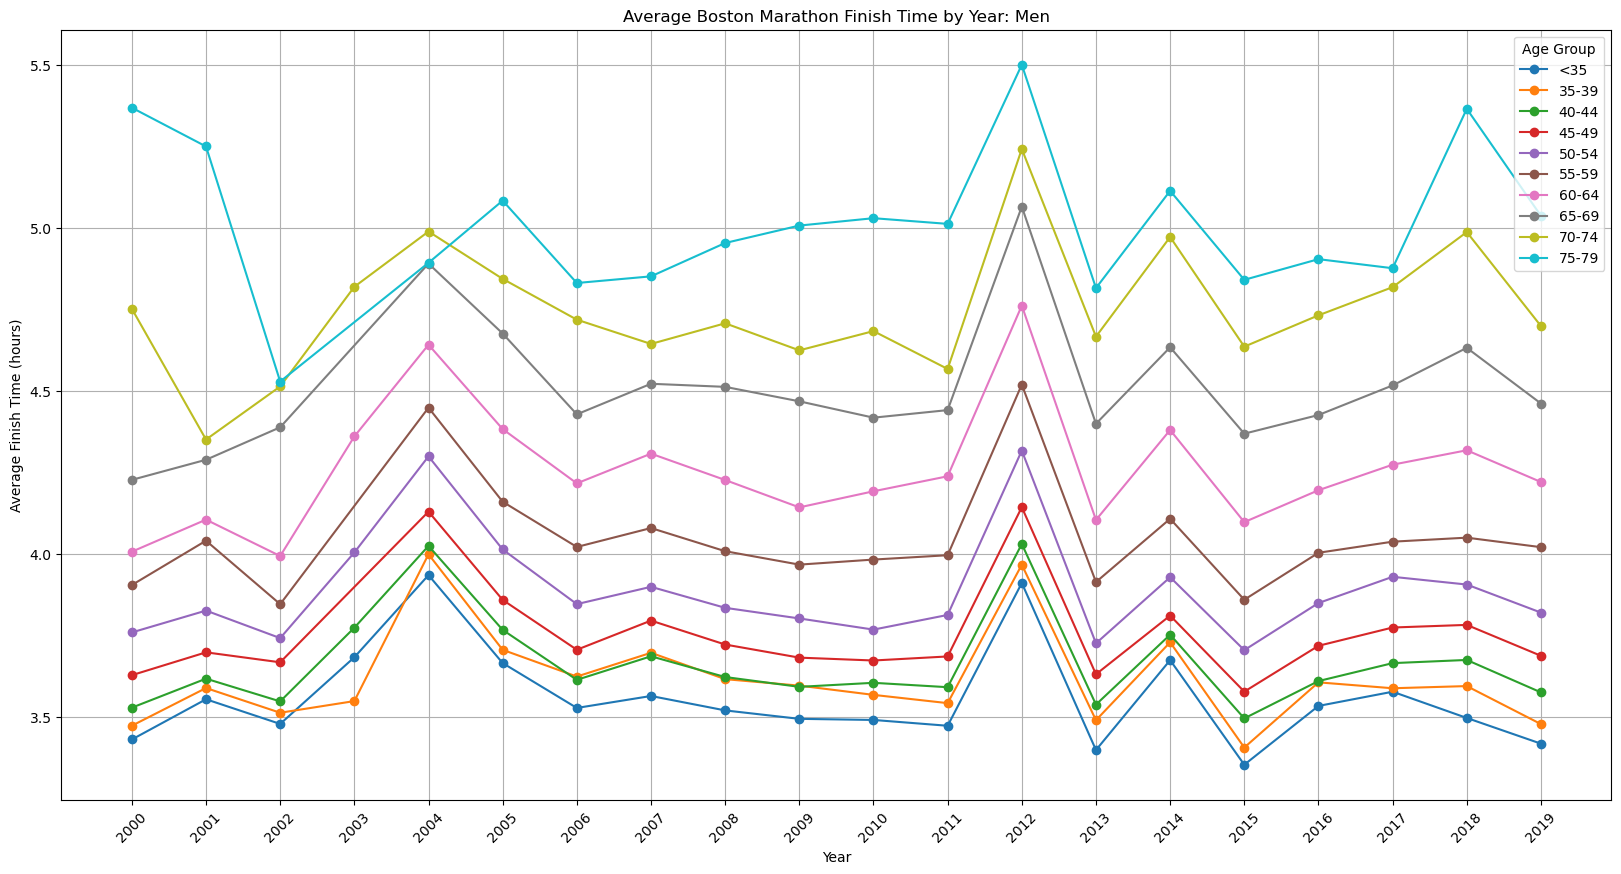

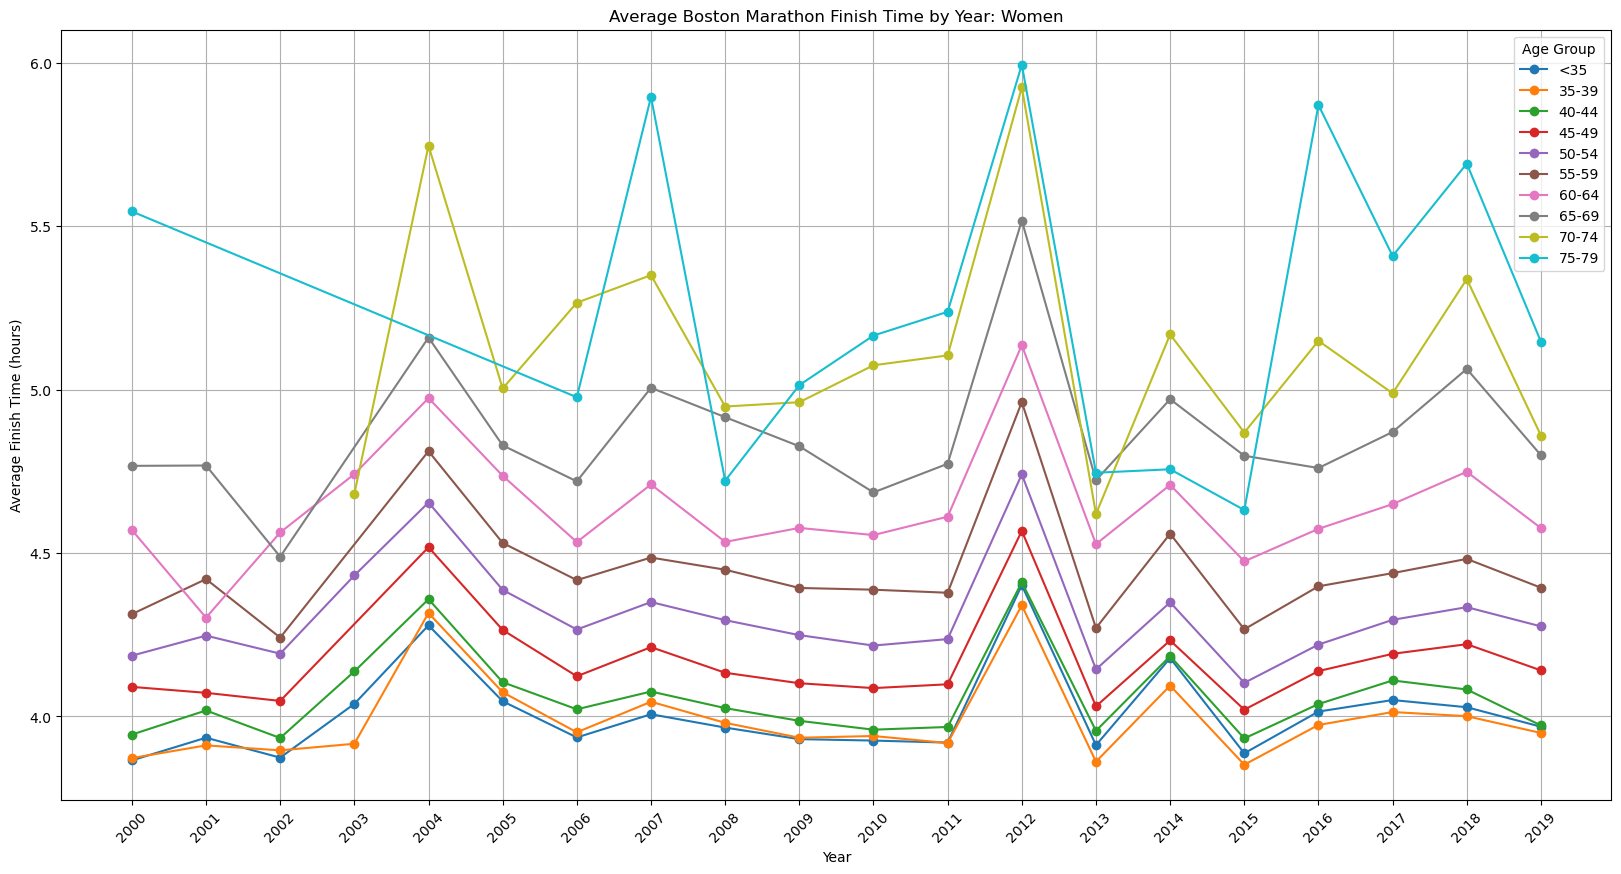

In [5]:
# Plot men's average finish time for each age group
plt.figure(figsize=(20, 10))

for age in age_groups:
    sub = men[men["age_group"] == age].sort_values("year")
    plt.plot(sub["year"], sub["mean"] / 3600, marker="o", label=age)

plt.xlabel("Year")
plt.ylabel("Average Finish Time (hours)")
plt.title("Average Boston Marathon Finish Time by Year: Men")
plt.legend(title="Age Group")
plt.xticks(np.arange(2000, 2020, 1), rotation=45)
plt.grid(True)
plt.show()

# Plot women's average finish time for each age group

plt.figure(figsize=(20, 10))

for age in age_groups:
    sub = women[women["age_group"] == age].sort_values("year")
    plt.plot(sub["year"], sub["mean"] / 3600, marker="o", label=age)

plt.xlabel("Year")
plt.ylabel("Average Finish Time (hours)")
plt.title("Average Boston Marathon Finish Time by Year: Women")
plt.legend(title="Age Group")
plt.xticks(np.arange(2000, 2020, 1), rotation=45)
plt.grid(True)
plt.show()

## Analysis

### Stage 1: Weather factor determination
First we need to figure out which, if any, weather factors contribute the most to average finish times for each age group.

#### Part 1: Mann-Whitney U Test (Wilcoxon rank-sum) -- temperature groups

Temperature over the 19 years with age group breakdowns is first broken up into two categories **Warm (>= 58 degrees), and Cool (< 58 degrees)**. Given that boston marathon training takes place in a cold city over the weather, one would expect that runners would be less prepared for warmer weather. So, the hypothesis for this test will be a one-sided Wilcoxon testing whether warmer weather correlated with slower finish times. This is broken down for each age group, to further study whether some age groups are more susceptible to weather conditions than others. Since the weather data and times data are not normally distributed, the Mann-Whitney U test (nonparameteric) is most applicable.

#### Hypotheses for Mann-Whitney U test (each age group)
- **H₀**: Warm weather finish times = cool weather finish times
- **Hₐ**: Warm weather finish times > cool weather finish times

In [6]:
from scipy.stats import kruskal, mannwhitneyu, spearmanr, linregress
import scikit_posthocs as sp
import seaborn as sns

In [7]:
# Men's age groups
results_temp_men = []
men["temp_group"] = men["max_temp"] > men["max_temp"].mean() + 1

for age in age_groups:
    sub = men[men["age_group"] == age]
    cool = sub[sub["temp_group"] == False]["mean_hours"]
    warm = sub[sub["temp_group"] == True]["mean_hours"]

    U, p = mannwhitneyu(cool, warm, alternative="less")
    results_temp_men.append({'age': age, 'n': len(sub), 'U': U, 'p': p})

df_temp_men = pd.DataFrame(results_temp_men)
df_temp_men

,age,n,U,p
0,<35,20,17.0,0.011803
1,35-39,20,20.0,0.022781
2,40-44,20,20.0,0.022781
3,45-49,19,10.0,0.002620
4,50-54,20,11.0,0.002335
5,55-59,19,12.0,0.004882
6,60-64,20,14.0,0.005573
7,65-69,19,12.0,0.004882
8,70-74,20,12.0,0.003173
9,75-79,19,30.0,0.170120


In [8]:
# Women's age groups
results_temp_women = []
women["temp_group"] = women["max_temp"] > women["max_temp"].mean() + 1

for i, age in enumerate(age_groups):
    sub = women[women["age_group"] == age]
    cool = sub[sub["temp_group"] == False]["mean_hours"]
    warm = sub[sub["temp_group"] == True]["mean_hours"]

    U, p = mannwhitneyu(cool, warm, alternative="less")
    results_temp_women.append({'age': age, 'n': len(sub), 'U': U, 'p': p})

df_temp_women = pd.DataFrame(results_temp_women)
df_temp_women

,age,n,U,p
0,<35,20,5.0,0.000245
1,35-39,20,8.0,0.000851
2,40-44,20,12.0,0.003173
3,45-49,19,6.0,0.000595
4,50-54,20,18.0,0.014848
5,55-59,19,13.0,0.006490
6,60-64,20,18.0,0.014848
7,65-69,19,20.0,0.034175
8,70-74,17,24.0,0.157394
9,75-79,15,16.0,0.154845


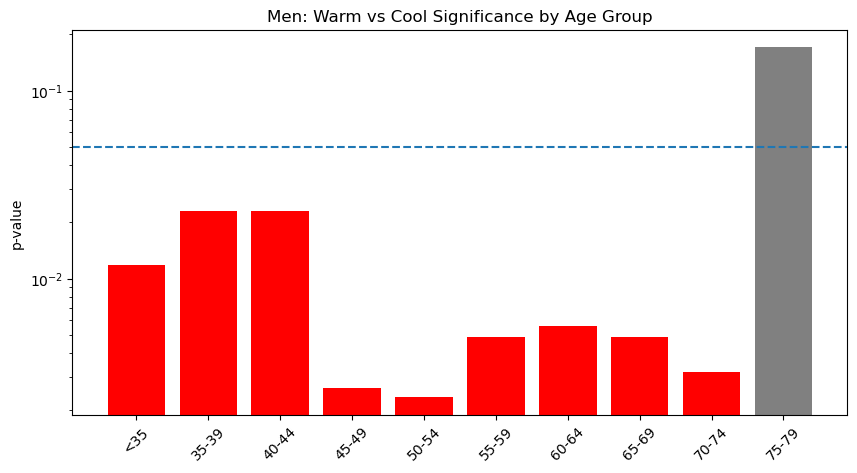

In [9]:
# Plot for men's temperature test results
x = np.arange(len(results_temp_men))
plt.figure(figsize=(10,5))
colors = ["red" if p < 0.05 else "gray"
          for p in df_temp_men['p']]
plt.bar(x, df_temp_men['p'], color=colors)
plt.axhline(0.05, linestyle="--")
plt.xticks(x, df_temp_men["age"], rotation=45)
plt.ylabel("p-value")
plt.yscale("log")
plt.title("Men: Warm vs Cool Significance by Age Group")
plt.show()

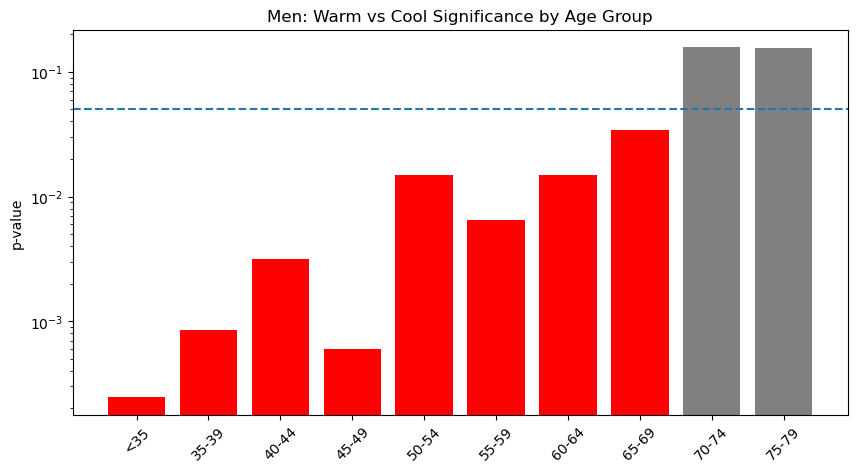

In [10]:
# Plot for women's temperature test results
plt.figure(figsize=(10,5))
colors = ["red" if p < 0.05 else "gray"
          for p in df_temp_women['p']]
plt.bar(x, df_temp_women['p'], color=colors)
plt.axhline(0.05, linestyle="--")
plt.xticks(x, df_temp_women["age"], rotation=45)
plt.ylabel("p-value")
plt.yscale("log")
plt.title("Men: Warm vs Cool Significance by Age Group")
plt.show()

#### Part 1 Results:

With p-values less than 0.05, all men's age groups <75 years old and all women's age groups <70 years old have strong evidence that suggests warmer temperature days indicate slower average finish times for both men and women.

#### Part 2: Mann-Whitney U Test (Wilcoxon rank-sum) -- humidity groups

Humidity over the 19 years with age group breakdowns is first broken up into two categories **Humid (>= 70%), and Not Humid (< 70%)**. The hypothesis for this test will be a one-sided Wilcoxon testing whether humid weather is correlated with slower finish times. This is broken down for each age group, to further study whether some age groups are more susceptible to weather conditions than others. Since the weather data and times data are not normally distributed, the Mann-Whitney U test (nonparameteric) is most applicable.

#### Hypotheses for Mann-Whitney U test (each age group)
- **H₀**: Humid weather finish times = Non-humid weather finish times
- **Hₐ**: Humid weather finish times > Non-humid weather finish times

In [11]:
# Men's age groups
results_humid_men = []
men["humid_group"] = men["mean_humidity"] >= 70

for i, age in enumerate(age_groups):
    sub = men[men["age_group"] == age]
    humid = sub[sub["humid_group"] == False]["mean_hours"]
    nohumid = sub[sub["humid_group"] == True]["mean_hours"]

    U, p = mannwhitneyu(nohumid, humid, alternative="less")
    results_humid_men.append({'age': age, 'n': len(sub), 'U': U, 'p': p})

df_humid_men = pd.DataFrame(results_humid_men)
df_humid_men

,age,n,U,p
0,<35,20,23.0,0.040557
1,35-39,20,34.0,0.196440
2,40-44,20,30.0,0.120679
3,45-49,19,32.0,0.215984
4,50-54,20,27.0,0.078715
5,55-59,19,28.0,0.130706
6,60-64,20,32.0,0.155689
7,65-69,19,41.0,0.483568
8,70-74,20,26.0,0.067402
9,75-79,19,31.0,0.192228


In [12]:
# Women's age groups
results_humid_women = []
women["humid_group"] = women["mean_humidity"] > 70

for i, age in enumerate(age_groups):
    sub = women[women["age_group"] == age]
    humid = sub[sub["humid_group"] == False]["mean_hours"]
    nohumid = sub[sub["humid_group"] == True]["mean_hours"]

    U, p = mannwhitneyu(nohumid, humid, alternative="less")
    results_humid_women.append({'age': age, 'n': len(sub), 'U': U, 'p': p})

df_humid_women = pd.DataFrame(results_humid_women)
df_humid_women

,age,n,U,p
0,<35,20,31.0,0.137461
1,35-39,20,38.0,0.294014
2,40-44,20,28.0,0.091344
3,45-49,19,35.0,0.295904
4,50-54,20,39.0,0.321324
5,55-59,19,32.0,0.215984
6,60-64,20,40.0,0.349587
7,65-69,19,50.0,0.758792
8,70-74,17,26.0,0.262443
9,75-79,15,21.0,0.264336


#### Part 2 Results:

With p-values greater than 0.05, we fail to reject the null-hypothesis. There is not enough evidence to support the claim that more humid days indicate slower average finish times for both men and women.

#### Part 3: Mann-Whitney U Test (Wilcoxon rank-sum) -- wind speed groups

Humidity over the 19 years with age group breakdowns is first broken up into two categories **Windy (>= 15 mph), and Not Windy (< 15 mph)**. The hypothesis for this test will be a one-sided Wilcoxon testing whether windy weather is correlated with slower finish times. This is broken down for each age group, to further study whether some age groups are more susceptible to weather conditions than others. Since the weather data and times data are not normally distributed, the Mann-Whitney U test (nonparameteric) is most applicable.

#### Hypotheses for Mann-Whitney U test (each age group)
- **H₀**: Windy day finish times = Non-windy day finish times
- **Hₐ**: Windy day finish times > Non-windy day finish times

In [13]:
# Men's age groups
results_wind_men = []
men["wind_group"] = men["mean_wind_mph"] >= 15

for i, age in enumerate(age_groups):
    sub = men[men["age_group"] == age]
    wind = sub[sub["wind_group"] == False]["mean_hours"]
    nowind = sub[sub["wind_group"] == True]["mean_hours"]

    U, p = mannwhitneyu(nowind, wind, alternative="less")
    results_wind_men.append({'age': age, 'n': len(sub), 'U': U, 'p': p})

df_wind_men = pd.DataFrame(results_wind_men)
df_wind_men

,age,n,U,p
0,<35,20,27.0,0.119556
1,35-39,20,24.0,0.076419
2,40-44,20,30.0,0.176522
3,45-49,19,31.0,0.260688
4,50-54,20,34.0,0.273323
5,55-59,19,32.0,0.289437
6,60-64,20,38.0,0.389525
7,65-69,19,34.0,0.350619
8,70-74,20,38.0,0.389525
9,75-79,19,40.0,0.550862


In [14]:
# Men's age groups
results_wind_women = []
women["wind_group"] = women["mean_wind_mph"] >= 15

for i, age in enumerate(age_groups):
    sub = women[women["age_group"] == age]
    wind = sub[sub["wind_group"] == False]["mean_hours"]
    nowind = sub[sub["wind_group"] == True]["mean_hours"]

    U, p = mannwhitneyu(nowind, wind, alternative="less")
    results_wind_women.append({'age': age, 'n': len(sub), 'U': U, 'p': p})

df_wind_women = pd.DataFrame(results_wind_women)
df_wind_women

,age,n,U,p
0,<35,20,31.0,0.198504
1,35-39,20,35.0,0.300774
2,40-44,20,32.0,0.222085
3,45-49,19,35.0,0.382685
4,50-54,20,33.0,0.246981
5,55-59,19,31.0,0.260688
6,60-64,20,47.0,0.670511
7,65-69,19,48.0,0.792238
8,70-74,17,35.0,0.712831
9,75-79,15,36.0,0.863936


#### Part 3 Results:

With p-values greater than 0.05, we fail to reject the null-hypothesis. There is not enough evidence to support the claim that more windy days indicate slower average finish times for both men and women.

### Stage 2: Temperature further Analysis

#### Part 1: Spearman Correlation Test
Based on the results of the Mann-Whitney U test, we can see that temperature shows the strongest monotonic association with average finish times. Next, we'll conduct a Spearman correlation test to answer **how much** temperature affects the average finish times for each age group.

#### Hypotheses: 
- **H₀**: ρ = 0
- **Hₐ**: ρ > 0

#### With Variables:
- **Y** = `mean_hours`
- **X** = `max_temp`

In [15]:
# Men's age groups
sp_results_temp_men = []

for i, age in enumerate(age_groups):
    sub = men[men["age_group"] == age]

    rho, p = spearmanr(sub["max_temp"], sub["mean_hours"])
    sp_results_temp_men.append({'age': age, 'n': len(sub), 'rho': rho, 'p': p})

df_sp_results_temp_men = pd.DataFrame(sp_results_temp_men)
df_sp_results_temp_men

,age,n,rho,p
0,<35,20,0.487751,0.029139
1,35-39,20,0.421411,0.064237
2,40-44,20,0.442519,0.050722
3,45-49,19,0.556096,0.013420
4,50-54,20,0.550322,0.011930
5,55-59,19,0.469866,0.042367
6,60-64,20,0.552584,0.011514
7,65-69,19,0.566655,0.011417
8,70-74,20,0.428196,0.059627
9,75-79,19,0.008799,0.971481


In [16]:
# Women's age groups
sp_results_temp_women = []

for i, age in enumerate(age_groups):
    sub = women[women["age_group"] == age]

    rho, p = spearmanr(sub["max_temp"], sub["mean_hours"])
    sp_results_temp_women.append({'age': age, 'n': len(sub), 'rho': rho, 'p': p})

df_sp_results_temp_women = pd.DataFrame(sp_results_temp_women)
df_sp_results_temp_women

,age,n,rho,p
0,<35,20,0.617416,0.003726
1,35-39,20,0.609124,0.004362
2,40-44,20,0.520168,0.018719
3,45-49,19,0.583373,0.008744
4,50-54,20,0.473428,0.034992
5,55-59,19,0.439949,0.059437
6,60-64,20,0.462874,0.039863
7,65-69,19,0.268369,0.266606
8,70-74,17,0.235873,0.362081
9,75-79,15,0.229806,0.409977


#### Part 1: Results
The Spearman Correlation test indicates that there is a strong positive correlation between average finish times and max temperature.

#### Part 2: Difference Magnitude (warm vs cool)
The first Mann-Whitney U test tested significance, but now we can start to quantify **how much** warm weather slows down average finish times.

First, we try and find the **magnitude** of the slowdown (in minutes) for each age group caused by warmer weather. 

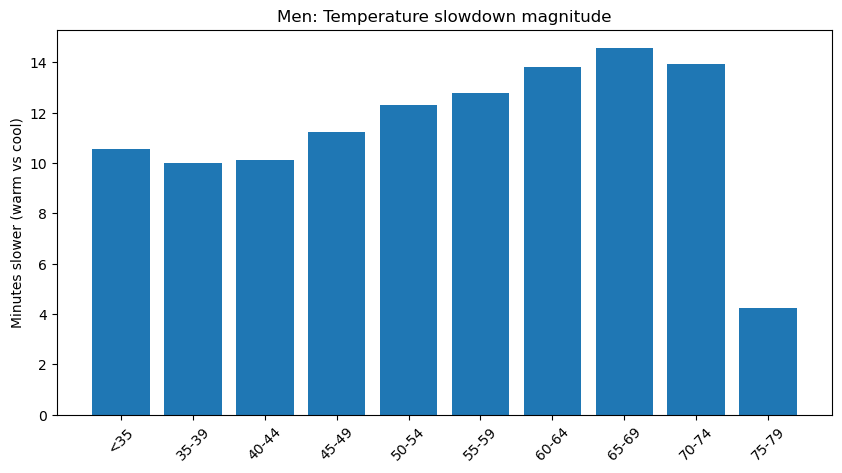

In [17]:
diff_results_men = []
for age in age_groups:
    sub = men[men["age_group"] == age]
    cool = sub[sub["temp_group"] == False]["mean_hours"]
    warm = sub[sub["temp_group"] == True]["mean_hours"]

    diff_mean = warm.mean() - cool.mean()
    diff_median = warm.median() - cool.median()
    pct = diff_mean / cool.mean() * 100

    diff_results_men.append({"age": age, "mean_diff_min": diff_mean * 60, "median_diff_min": diff_median * 60, "percent": pct})

df_diff_men = pd.DataFrame(diff_results_men)

plt.figure(figsize=(10,5))
plt.bar(df_diff_men["age"], df_diff_men["mean_diff_min"])
plt.ylabel("Minutes slower (warm vs cool)")
plt.xticks(rotation=45)
plt.title("Men: Temperature slowdown magnitude")
plt.show()

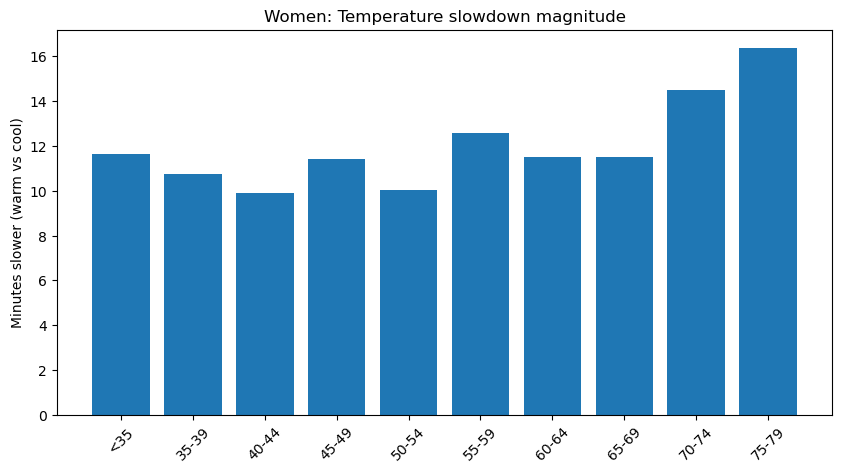

In [18]:
diff_results_women = []
for age in age_groups:
    sub = women[women["age_group"] == age]
    cool = sub[sub["temp_group"] == False]["mean_hours"]
    warm = sub[sub["temp_group"] == True]["mean_hours"]

    diff_mean = warm.mean() - cool.mean()
    diff_median = warm.median() - cool.median()
    pct = diff_mean / cool.mean() * 100

    diff_results_women.append({"age": age, "mean_diff_min": diff_mean * 60, "median_diff_min": diff_median * 60, "percent": pct})

df_diff_women = pd.DataFrame(diff_results_women)

plt.figure(figsize=(10,5))
plt.bar(df_diff_women["age"], df_diff_women["mean_diff_min"])
plt.ylabel("Minutes slower (warm vs cool)")
plt.xticks(rotation=45)
plt.title("Women: Temperature slowdown magnitude")
plt.show()

#### Part 2: Results
Looking at the magnitude of the difference, across all age groups in both men and women, we can see that the warm weather days had on average **+ 10 minutes** to finish times. 

#### Part 3:

Last, we'll find the linear regression of slowdown (increase of average finish time) per degree increase of max temperature. Although data are not normally distributed, regression is used to estimate effect size rather than hypothesis testing.

#### Model:
**mean_hours = β0 + β1 * temperature**

Where β1 is the slope and equals the minutes slower per degree

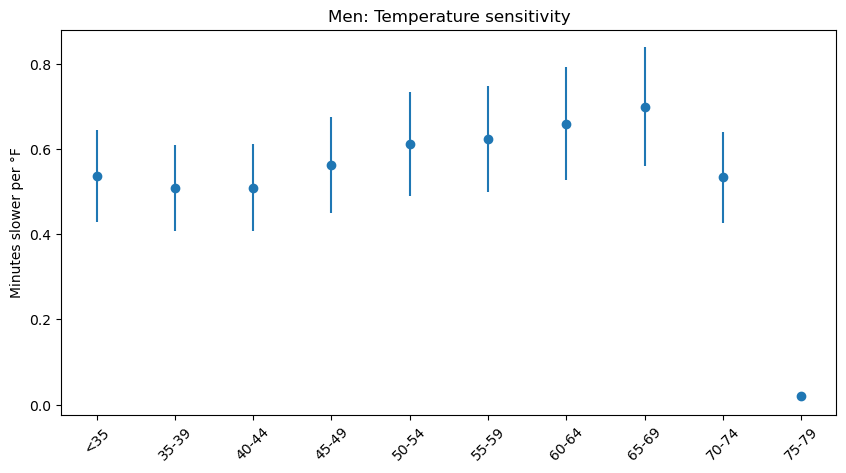

In [19]:
reg_results_men = []

for age in age_groups:
    sub = men[men["age_group"] == age]
    slope, intercept, r, p, se = linregress(sub["max_temp"], sub["mean_hours"])
    reg_results_men.append({"age": age, "slope_min_per_F": slope * 60, "rho": r, "p": p})

df_reg_men = pd.DataFrame(reg_results_men)


plt.figure(figsize=(10,5))
plt.errorbar(
    df_reg_men["age"],
    df_reg_men["slope_min_per_F"],
    yerr=df_reg_men["slope_min_per_F"]*0.2,
    fmt="o"
)
plt.ylabel("Minutes slower per °F")
plt.xticks(rotation=45)
plt.title("Men: Temperature sensitivity")
plt.show()

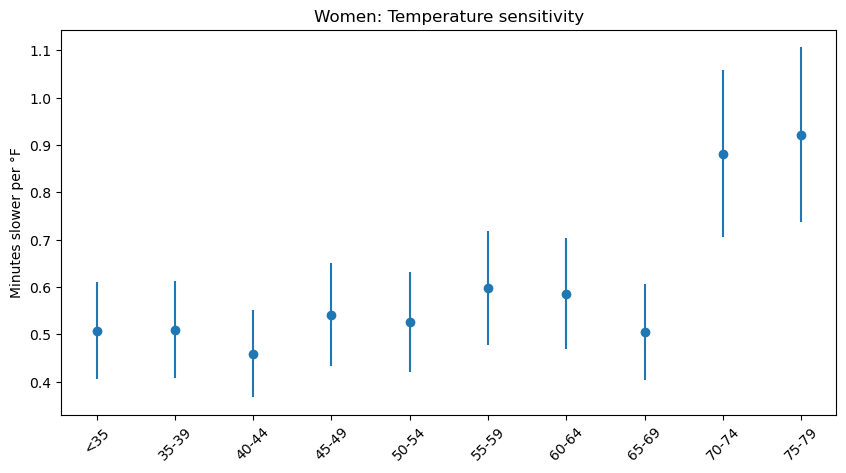

In [20]:
reg_results_women = []

for age in age_groups:
    sub = women[women["age_group"] == age]
    slope, intercept, r, p, se = linregress(sub["max_temp"], sub["mean_hours"])
    reg_results_women.append({"age": age, "slope_min_per_F": slope * 60, "rho": r, "p": p})

df_reg_women = pd.DataFrame(reg_results_women)


plt.figure(figsize=(10,5))
plt.errorbar(
    df_reg_women["age"],
    df_reg_women["slope_min_per_F"],
    yerr=df_reg_women["slope_min_per_F"]*0.2,
    fmt="o"
)
plt.ylabel("Minutes slower per °F")
plt.xticks(rotation=45)
plt.title("Women: Temperature sensitivity")
plt.show()

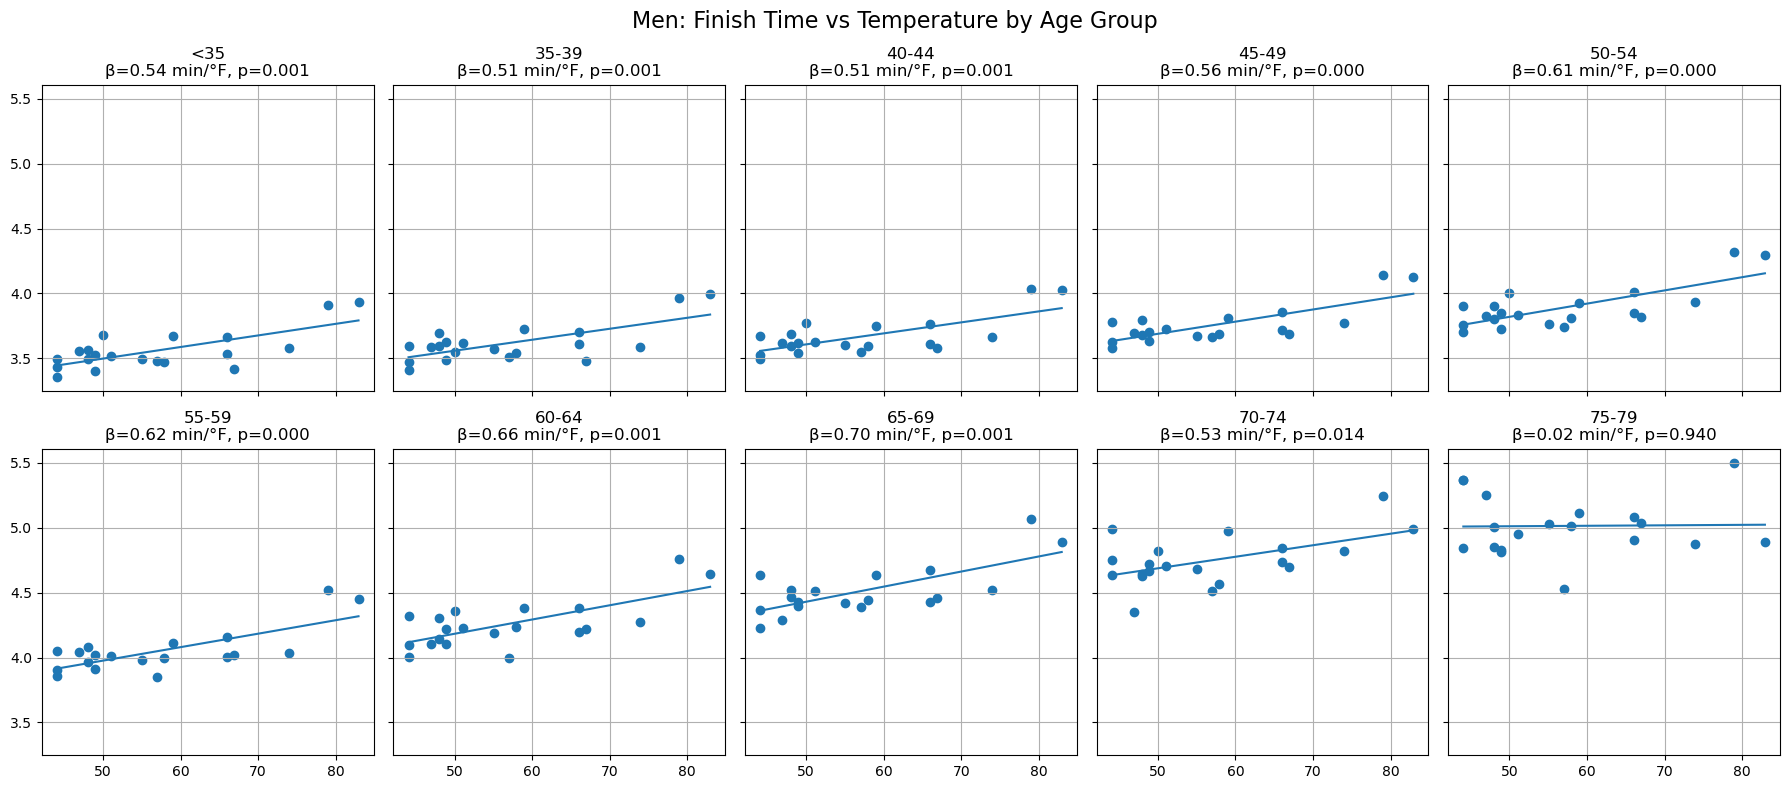

In [21]:
## Regression Plots on Scatter plot of data
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i, age in enumerate(age_groups):

    sub = men[men["age_group"] == age]
    x = sub["max_temp"]
    y = sub["mean_hours"]
    slope, intercept, r, p, se = linregress(x, y)

    axes[i].scatter(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line
    axes[i].plot(x_line, y_line)
    axes[i].set_title(
        f"{age}\nβ={slope*60:.2f} min/°F, p={p:.3f}"
    )
    axes[i].grid(True)

fig.suptitle("Men: Finish Time vs Temperature by Age Group", fontsize=16)
plt.tight_layout()
plt.show()

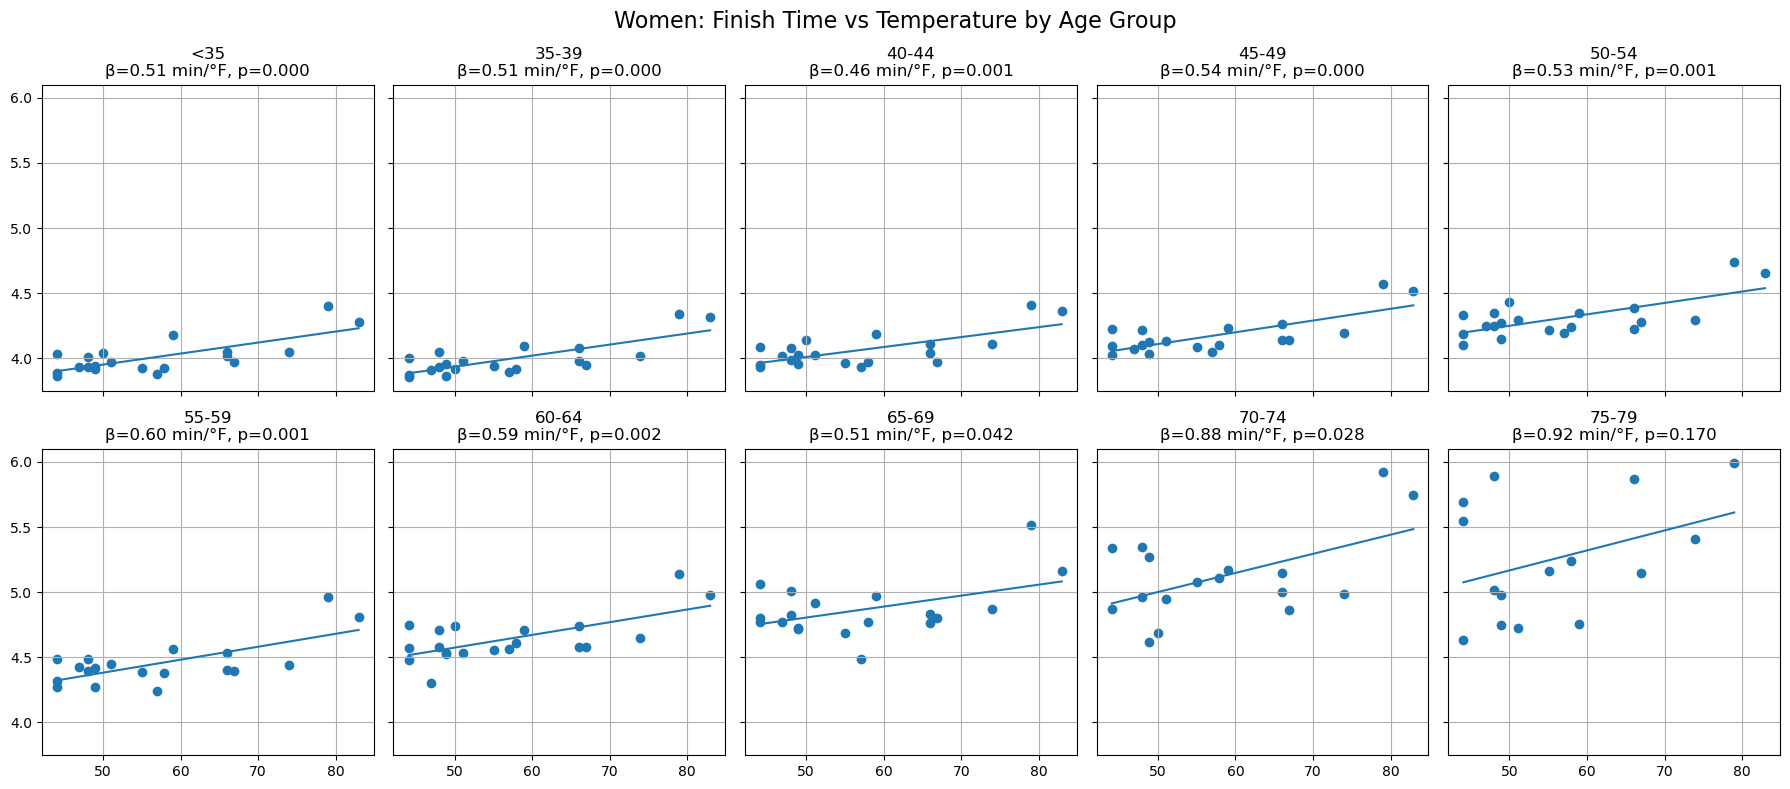

In [22]:
## Regression Plots on Scatter plot of data
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i, age in enumerate(age_groups):

    sub = women[women["age_group"] == age]
    x = sub["max_temp"]
    y = sub["mean_hours"]
    slope, intercept, r, p, se = linregress(x, y)

    axes[i].scatter(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line
    axes[i].plot(x_line, y_line)
    axes[i].set_title(
        f"{age}\nβ={slope*60:.2f} min/°F, p={p:.3f}"
    )
    axes[i].grid(True)

fig.suptitle("Women: Finish Time vs Temperature by Age Group", fontsize=16)
plt.tight_layout()
plt.show()

# Study Summary: Effect of Temperature on Boston Marathon Finish Times

## Research Objective

The objective of this study was to determine whether race-day temperature affects Boston Marathon finish times and whether this effect varies by age group and gender. Specifically, the analysis aimed to evaluate whether warmer temperatures are associated with slower average finish times and to quantify how much performance changes as temperature increases.

---

## Statistical Formulation of the Problem

This research problem was formulated by modeling finish time as a function of race-day temperature. The independent variable is maximum race-day temperature, and the dependent variable is average marathon finish time. The data were divided into multiple populations defined by sex and age group, with each age-sex group analyzed separately. Each observation corresponds to a single year of the Boston Marathon, making yearly results independent samples.

Let:

- **Y** = average finish time (hours)  
- **X** = maximum race-day temperature (°F)

A plausible probability model is:

**Y = β0 + β1 X + eps**

where:

- **β0** = baseline finish time  
- **β1** = increase in finish time per degree increase in temperature  
- **eps** = random variation due to other factors  

This model assumes that temperature influences finish time with random variation across years.

---

## Choice of Statistical Techniques and Assumptions

Exploratory analysis showed that finish time distributions were not normally distributed. Because of this, nonparametric statistical techniques were selected. The Mann–Whitney U test was used to compare finish times between warm and cool race days, and Spearman rank correlation was used to measure the monotonic relationship between temperature and finish time. Linear regression was additionally used to estimate the magnitude of slowdown per degree increase in temperature.

The assumptions for these methods include:

- Observations are independent across years  
- Finish times are continuous measurements  
- Temperature is measured on a continuous scale  
- The relationship between temperature and finish time is approximately monotonic  
- Linear regression assumes approximate linearity for estimating effect size  

These assumptions are reasonable because each year's marathon is independent, the variables are continuous, and scatterplots suggested a monotonic increasing relationship between temperature and finish time.

---

## Results and Interpretation

The analysis demonstrated consistent evidence that warmer temperatures are associated with slower Boston Marathon finish times. The Mann–Whitney U tests showed statistically significant differences between warm and cool race days for most age groups, indicating that runners tend to finish later when temperatures are higher. Spearman correlation tests confirmed a positive monotonic relationship between temperature and average finish time across both men and women in most age groups.

Linear regression analysis quantified this effect and showed that average finish times increase as temperature rises. Across groups, warmer race days resulted in noticeably slower performances, with many age groups showing approximately a ten-minute increase in finish time on warmer days. Younger and middle-aged runners appeared to show the strongest sensitivity to temperature changes, while older age groups showed weaker but still positive trends.

Overall, the results support the conclusion that higher race-day temperatures lead to slower marathon performances. Temperature is therefore an important environmental factor affecting Boston Marathon finish times, and its impact varies somewhat across demographic groups but remains consistently positive across most populations.